# LLM-Assisted Cyber Threat Intelligence for 5G O-RAN Security

**Pipeline overview:**
1. Load dataset — NetsLab-5GORAN-IDD (Network_dataset)
2. EDA — class distribution, feature stats, correlation matrix
3. Preprocessing — label-encode categoricals, drop leakage columns, SMOTE-balance minority classes, stratified 80/20 split
4. Train XGBoost (`multi:softprob`) — outputs full class probabilities
5. Evaluate — accuracy, macro F1, confusion matrix, error analysis
6. CTI Alert — ML output → structured JSON alert per O-RAN component
7. SHAP — per-prediction TreeExplainer feature importance, injected into the alert
8. LLM Enrichment — Qwen2.5-7B via Ollama contextualises the alert
9. LLM Evaluation — hallucination check, timing, with/without SHAP comparison
10. LLM Fine-Tuning — LoRA/QLoRA on a CTI corpus; base vs fine-tuned; incident report
11. Full Demo — end-to-end run on a single test event

---
## Section 0: Setup

Installs required packages and mounts Google Drive for dataset and model access.

In [1]:
# Install dependencies
%pip install xgboost shap matplotlib seaborn scikit-learn pandas numpy ollama imbalanced-learn -q

In [2]:
# Mount Google Drive — put Network_Dataset.csv in Drive under a CTI/ folder
from google.colab import drive
drive.mount('/content/drive')

# ---- update these paths to match where the files live in Drive ----
CSV_PATH        = '/content/drive/MyDrive/CTI/Network_Dataset.csv'
DB_PATH         = '/content/drive/MyDrive/CTI/Network_Dataset.db'  # fallback
MODEL_SAVE_PATH = '/content/drive/MyDrive/CTI/xgb_model.json'
# -------------------------------------------------------------------

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports OK')

All imports OK


In [4]:
# Verify GPU availability
import torch
if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU available, using CPU instead.')

!nvidia-smi

Using GPU: Tesla T4
Fri Jul  3 14:46:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

---
## Section 1: Load Data

Loads from CSV (falls back to SQLite if CSV isn't present). The dataset has 1,723,817 rows and 26 columns — pre-processed Zeek flow features from the NetsLab-5GORAN-IDD dataset.

In [5]:
import os

# Prefer CSV — simpler and no sqlite3 needed
# Falls back to SQLite if CSV is missing
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded from CSV: {CSV_PATH}")
else:
    import sqlite3
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM network_data", conn)
    conn.close()
    print(f"Loaded from SQLite: {DB_PATH}")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded from CSV: /content/drive/MyDrive/CTI/Network_Dataset.csv
Shape: (1723817, 26)
Columns: ['uid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'attack_type', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered', 'traffic_type']


,uid,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dst_ip_bytes,ip_proto,http_trans_depth,attack_category,attack_type,files_total_bytes,is_GET_mthd,http_status_error,is_file_transfered,traffic_type
0,CgvPTm2yEMy1O7Jl9k,192.168.0.1,18728,192.168.0.10,80,tcp,-,0.000041,0.0,0.0,...,40,6,0,ddos,tcp_ack,0.0,0,0,0,1
1,CAOgXB1yv9VtvISnDc,172.16.0.3,29039,192.168.0.10,80,tcp,-,0.000746,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1
2,CXyf8S2WNJVYWlDI15,172.31.0.134,7552,192.168.0.10,80,tcp,-,0.000086,0.0,0.0,...,88,6,0,ddos,syn,0.0,0,0,0,1
3,CXjeD72LNi8Cn2EXZ5,172.16.0.4,59569,52.207.202.187,443,tcp,-,594.651675,73426.0,14841.0,...,55360,6,0,ddos,icmp,0.0,0,0,0,1
4,CgGkxuR9gLRepT5j2,172.16.0.3,42502,192.168.0.10,80,tcp,-,0.000290,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1


---
## Section 2: EDA

Exploratory analysis of the NetsLab-5GORAN-IDD dataset — class distribution, feature statistics, and correlation structure.

### 2.1 — Null Check

In [6]:
null_counts = df.isnull().sum()
print('Null counts per column:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No null values — dataset is complete.')

Null counts per column:
No null values — dataset is complete.


### 2.2 — Class Distribution

Class distribution (attack_category):
attack_category
dos           632507
ddos          420282
web           288304
probe         183293
benign        170865
bruteforce     28566
Name: count, dtype: int64

Total samples: 1,723,817


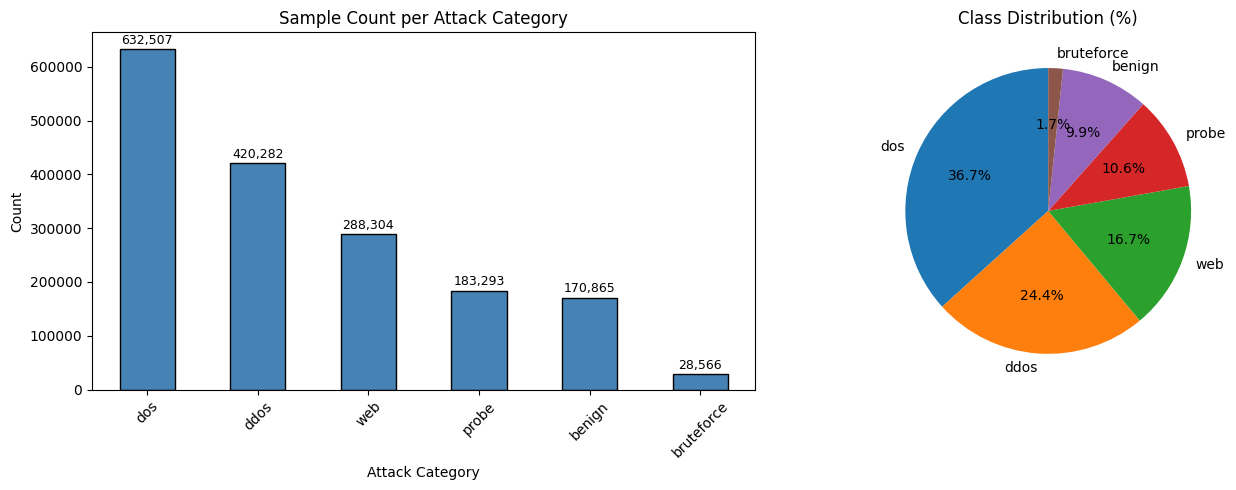

Plot saved.


In [7]:
# attack_category is the ML target (coarse: ddos, dos, probe, etc.)
# attack_type has finer detail (e.g., ddos_syn) — kept out of model features, used in CTI alert only

class_counts = df['attack_category'].value_counts()
print('Class distribution (attack_category):')
print(class_counts)
print(f'\nTotal samples: {len(df):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Count per Attack Category')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 2.3 — Attack Types
*Fine-grained breakdown by category — used in CTI alert generation, not as model features.*

In [8]:
print('Attack types per category:')
print(df.groupby(['attack_category', 'attack_type']).size().to_string())

Attack types per category:
attack_category  attack_type      
benign           benign               170865
bruteforce       ftp                   13664
                 ssh                   14902
ddos             icmp                  11217
                 slowloris             18649
                 syn                  174087
                 tcp_ack              154084
                 udp                   62245
dos              icmp                  13522
                 slowloris             76238
                 syn                  332364
                 tcp_ack               45220
                 udp                  165163
probe            os_fingerprinting     62957
                 portscan_tcp         100000
                 portscan_udp          20336
web              dir_bruteforce        28566
                 http_flood           254314
                 sql_injection          1763
                 xss                    3661


### 2.4 — Categorical Features
*Unique value counts for columns that require label encoding.*

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')
print()
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    if df[col].nunique() <= 20:
        print(f'  Values: {sorted(df[col].unique().tolist())}')

Categorical columns: ['uid', 'src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'history', 'attack_category', 'attack_type']

uid: 1604266 unique values
src_ip: 318 unique values
dst_ip: 1391 unique values
proto: 4 unique values
  Values: ['icmp', 'tcp', 'udp', 'unknown_transport']
service: 15 unique values
  Values: ['-', 'ayiya', 'dhcp', 'dns', 'dtls', 'ftp', 'gtpv1', 'http', 'krb_tcp', 'ldap_udp', 'ntp', 'quic', 'quic,ssl', 'ssh', 'ssl']
conn_state: 13 unique values
  Values: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'RSTRH', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH', 'SHR']
history: 3796 unique values
attack_category: 6 unique values
  Values: ['benign', 'bruteforce', 'ddos', 'dos', 'probe', 'web']
attack_type: 15 unique values
  Values: ['benign', 'dir_bruteforce', 'ftp', 'http_flood', 'icmp', 'os_fingerprinting', 'portscan_tcp', 'portscan_udp', 'slowloris', 'sql_injection', 'ssh', 'syn', 'tcp_ack', 'udp', 'xss']


### 2.5 — Mutual Information Feature Relevance
*Scores each feature by how much it reduces uncertainty about the target class.*
*Identifier and leakage columns are excluded; all others including `history` are scored.*

In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder as _LE

# Exclude identifiers and leakage columns — not modelling candidates
EXCLUDE = ['uid', 'src_ip', 'dst_ip', 'attack_type', 'traffic_type', 'attack_category']
mi_df = df.drop(columns=EXCLUDE).copy()

# Temporarily label-encode all remaining categoricals (including history)
# MI only needs numeric input — the encoding is for scoring only, not modelling
for col in mi_df.select_dtypes(include='object').columns:
    mi_df[col] = _LE().fit_transform(mi_df[col].astype(str))

# Target: exclude bruteforce to match the actual modelling target
_mask = df['attack_category'] != 'bruteforce'
X_mi = mi_df[_mask]
y_mi = _LE().fit_transform(df.loc[_mask, 'attack_category'])

print('Computing mutual information scores (this may take ~30s)...')
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print('\nMutual Information scores (higher = more relevant to target):')
print(mi_series.to_string())

Computing mutual information scores (this may take ~30s)...

Mutual Information scores (higher = more relevant to target):
src_ip_bytes          1.028971
history               0.954656
duration              0.842530
dst_ip_bytes          0.819347
src_port              0.765893
src_bytes             0.737775
conn_state            0.695890
dst_bytes             0.694547
src_pkts              0.616512
files_total_bytes     0.601623
dst_pkts              0.558250
http_trans_depth      0.488200
dst_port              0.478597
is_file_transfered    0.472722
service               0.455446
http_status_error     0.441877
is_GET_mthd           0.394976
proto                 0.102877
ip_proto              0.094088
missed_bytes          0.000374


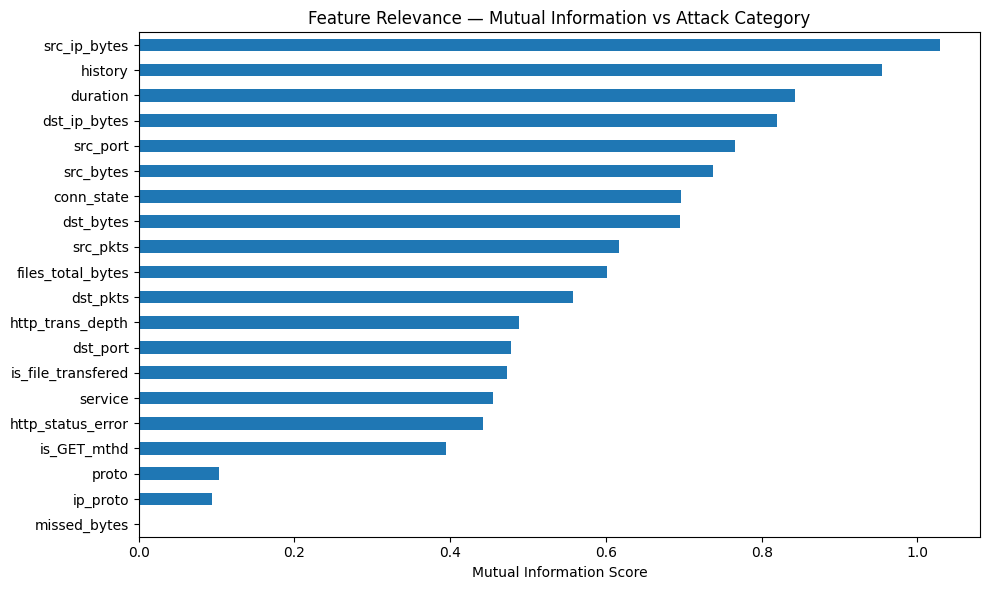

Saved: mi_feature_relevance.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
mi_series.plot(kind='barh', ax=ax, color='#1f77b4')
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Relevance — Mutual Information vs Attack Category')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/mi_feature_relevance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mi_feature_relevance.png')

### 2.6 — Correlation Matrix (Numeric Features)
*Pearson correlation to identify redundant continuous features. Pairs with |r| > 0.95 are candidates for removal.*

*String categoricals (`proto`, `service`, `conn_state`) are excluded automatically (non-numeric). `ip_proto`, `src_port`, `dst_port` (integer-coded categoricals/ports) and the `traffic_type` leakage flag are excluded explicitly — Pearson correlation on these is meaningless.* 

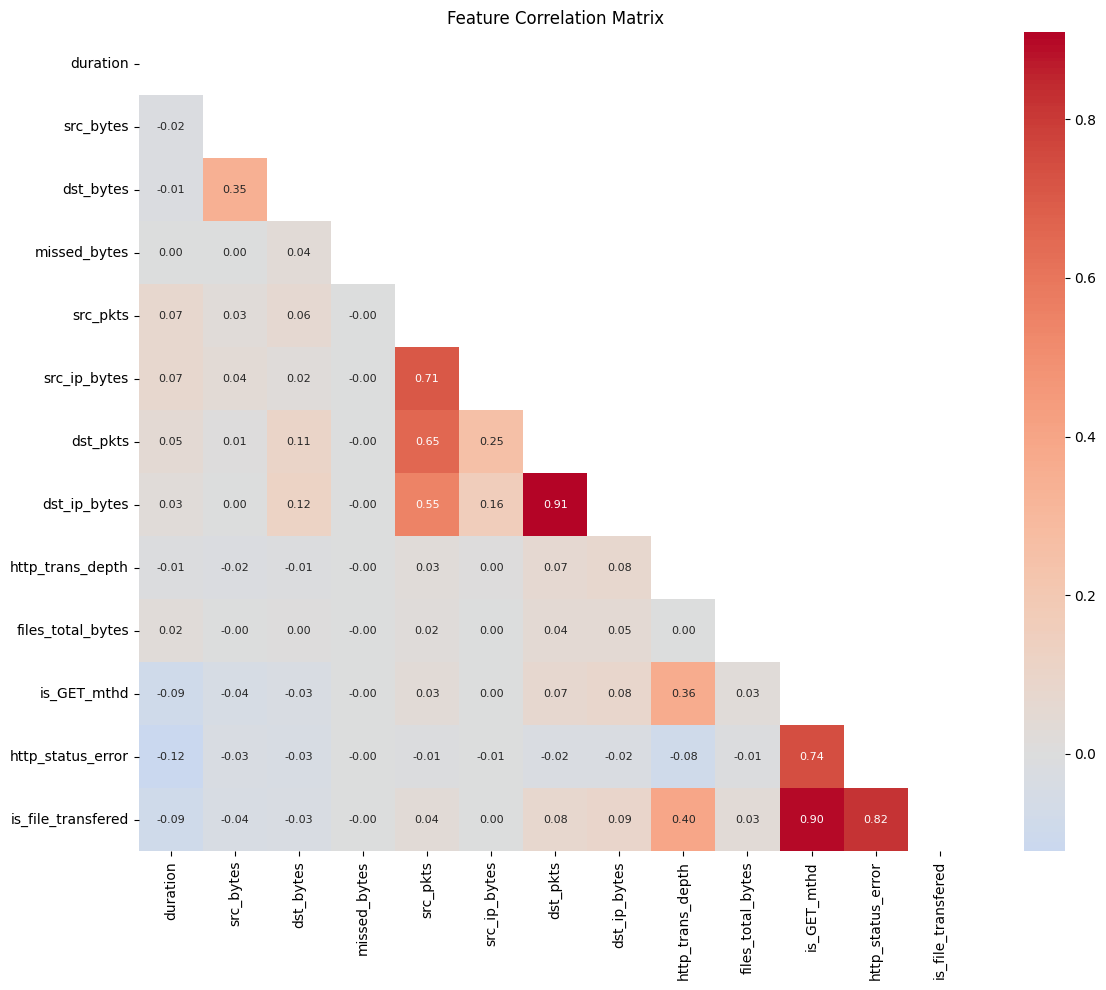

No highly correlated pairs found (|r| > 0.95).


In [12]:
# Numeric columns only.
# ip_proto is stored as int but is semantically categorical (1=ICMP, 6=TCP, 17=UDP).
# traffic_type is a binary label-leakage column — excluded from all feature analysis.
# src_port/dst_port are integer identifiers (ephemeral/service ports), not continuous features.
EXCLUDE_FROM_CORR = ['ip_proto', 'traffic_type', 'src_port', 'dst_port']
numeric_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in EXCLUDE_FROM_CORR]

numeric_df = df[numeric_cols]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (|r| > 0.95)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr:
    print('Highly correlated pairs (|r| > 0.95):')
    for a, b, r in high_corr:
        print(f'  {a} <-> {b}: r={r}')
else:
    print('No highly correlated pairs found (|r| > 0.95).')

---
## Section 3: Preprocessing

| Action | Columns | Reason |
|--------|---------|--------|
| Drop | `uid`, `src_ip`, `dst_ip` | Identifiers — no generalisable signal, overfitting risk |
| Drop | `attack_type`, `traffic_type` | Label leakage — encode the target directly |
| Drop | `history` | 3,796 unique Zeek sequences — encoding infeasible; `conn_state` captures the signal |
| Drop | `missed_bytes` | MI ≈ 0 — no discriminative signal |
| Label encode | `proto`, `service`, `conn_state` | Categorical → integer; XGBoost splits on thresholds, no one-hot needed |
| Keep | All remaining numeric columns | XGBoost doesn't require scaling |
| Target encode | `attack_category` | String class → integer index for `multi:softprob` |

### 3.1 — Drop Columns & Exclude Bruteforce

| Column(s) | Reason |
|---|---|
| `uid`, `src_ip`, `dst_ip` | Identifiers — no generalisable signal, overfitting risk |
| `attack_type`, `traffic_type` | Label leakage — encode the target directly |
| `history` | MI rank 2 (0.955) but 3,796 unique Zeek sequences — encoding infeasible; `conn_state` captures the signal |
| `missed_bytes` | MI ≈ 0 — no discriminative signal |

In [13]:
DROP_COLS = ['uid', 'src_ip', 'dst_ip', 'attack_type', 'traffic_type', 'history',
             'missed_bytes']  # missed_bytes: MI≈0 — no discriminative signal
TARGET_COL = 'attack_category'

df = df[df[TARGET_COL] != 'bruteforce'].copy()
print(f'Rows after removing bruteforce: {len(df):,}')

counts = df[TARGET_COL].value_counts()
total = counts.sum()
print('\nClass distribution:')
for cls, cnt in counts.items():
    print(f'  {cls}: {cnt:,} ({cnt/total*100:.1f}%)')

df_model = df.drop(columns=DROP_COLS)
print(f'\nColumns after dropping: {list(df_model.columns)}')
print(f'Shape: {df_model.shape}')


Rows after removing bruteforce: 1,695,251

Class distribution:
  dos: 632,507 (37.3%)
  ddos: 420,282 (24.8%)
  web: 288,304 (17.0%)
  probe: 183,293 (10.8%)
  benign: 170,865 (10.1%)

Columns after dropping: ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered']
Shape: (1695251, 19)


### 3.2 — Encode Categorical Features
*LabelEncoder on `proto`, `service`, `conn_state`. Encoders saved for inverse-transform in alert generation.*

In [14]:
# Saving encoders for inverse-transform in alert generation

CATEGORICAL_COLS = ['proto', 'service', 'conn_state']
feature_encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    feature_encoders[col] = le
    print(f'{col}: {len(le.classes_)} unique values → {list(le.classes_)}')

proto: 4 unique values → ['icmp', 'tcp', 'udp', 'unknown_transport']
service: 14 unique values → ['-', 'ayiya', 'dhcp', 'dns', 'dtls', 'gtpv1', 'http', 'krb_tcp', 'ldap_udp', 'ntp', 'quic', 'quic,ssl', 'ssh', 'ssl']
conn_state: 13 unique values → ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'RSTRH', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH', 'SHR']


### 3.3 — Encode Target Label

In [15]:
# XGBoost needs integer class indices, not strings

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_model[TARGET_COL])
X = df_model.drop(columns=[TARGET_COL])

CLASS_NAMES = list(target_encoder.classes_)   
NUM_CLASSES = len(CLASS_NAMES)

print(f'Feature matrix shape: {X.shape}')
print(f'Target classes: {CLASS_NAMES}')
print(f'Class indices: {dict(enumerate(CLASS_NAMES))}')

Feature matrix shape: (1695251, 18)
Target classes: ['benign', 'ddos', 'dos', 'probe', 'web']
Class indices: {0: 'benign', 1: 'ddos', 2: 'dos', 3: 'probe', 4: 'web'}


### 3.4 — Train/Test Split
*Stratified 80/20 split — preserves class proportions in both sets.*

In [16]:
# Stratified so each class appears in train/test in the same proportion as the full dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print()
print('Class distribution in test set:')
for i, cls in enumerate(CLASS_NAMES):
    count = np.sum(y_test == i)
    print(f'  {cls}: {count:,} ({count/len(y_test)*100:.1f}%)')

Training set: 1,356,200 samples
Test set:     339,051 samples

Class distribution in test set:
  benign: 34,173 (10.1%)
  ddos: 84,056 (24.8%)
  dos: 126,502 (37.3%)
  probe: 36,659 (10.8%)
  web: 57,661 (17.0%)


### 3.5 — Class Balancing
*SMOTE upsamples minorities; RandomUnderSampler reduces majorities. Target: 200k per class.*

In [17]:
# SMOTE upsamples minority classes (benign ~137k, probe ~147k) to 200k.
# RandomUnderSampler brings majority classes (dos ~506k, ddos ~336k, web ~231k) down to 200k.
# Result: 5 classes × 200k = 1M balanced training samples.
# Target of 200k chosen as it sits just above the natural minorities —
# minimal synthetic data needed, and majority classes are cut to a manageable size.

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

TARGET_PER_CLASS = 200_000

u, c = np.unique(y_train, return_counts=True)
current = dict(zip(u.tolist(), c.tolist()))

over_targets  = {cls: TARGET_PER_CLASS for cls, cnt in current.items() if cnt < TARGET_PER_CLASS}
under_targets = {cls: TARGET_PER_CLASS for cls, cnt in current.items() if cnt > TARGET_PER_CLASS}

print('Upsampling  (SMOTE):', [(CLASS_NAMES[k], v) for k, v in over_targets.items()])
print('Downsampling (RUS): ', [(CLASS_NAMES[k], v) for k, v in under_targets.items()])

smote = SMOTE(sampling_strategy=over_targets,  random_state=RANDOM_STATE, k_neighbors=5)
under = RandomUnderSampler(sampling_strategy=under_targets, random_state=RANDOM_STATE)
pipe  = Pipeline([('smote', smote), ('under', under)])

X_res, y_res = pipe.fit_resample(X_train, y_train)

print(f'\nResampled train set: {X_res.shape[0]:,} rows (was {X_train.shape[0]:,})')
u2, c2 = np.unique(y_res, return_counts=True)
print('Class counts after balancing:')
for cls_idx, cnt in zip(u2, c2):
    print(f'  {CLASS_NAMES[cls_idx]}: {cnt:,}')

Upsampling  (SMOTE): [('benign', 200000), ('probe', 200000)]
Downsampling (RUS):  [('ddos', 200000), ('dos', 200000), ('web', 200000)]

Resampled train set: 1,000,000 rows (was 1,356,200)
Class counts after balancing:
  benign: 200,000
  ddos: 200,000
  dos: 200,000
  probe: 200,000
  web: 200,000


---
## Section 4: Train XGBoost Model

XGBoost was selected over Random Forest and neural networks for three reasons:
- Consistently strong performance on structured tabular data
- `multi:softprob` outputs a full probability distribution over classes, providing confidence scores for CTI alert generation
- TreeExplainer (SHAP) computes exact Shapley values for tree models efficiently

### 4.1 — Train Model

In [18]:
# No sample_weight required here — SMOTE already balanced the training set.
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',   # outputs full probability distribution
    num_class=NUM_CLASSES,
    eval_metric='mlogloss',
    use_label_encoder=False,
    tree_method='hist',           # fastest training method, GPU-compatible
    device='cuda',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Training XGBoost on SMOTE-resampled data...')
start = time.time()

model.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

elapsed = time.time() - start
print(f'\nTraining complete in {elapsed:.1f}s')

model.save_model(MODEL_SAVE_PATH)
print(f'Model saved to {MODEL_SAVE_PATH}')

Training XGBoost on SMOTE-resampled data...
[0]	validation_0-mlogloss:1.41157
[50]	validation_0-mlogloss:0.15127
[100]	validation_0-mlogloss:0.12209
[150]	validation_0-mlogloss:0.11228
[200]	validation_0-mlogloss:0.10752
[250]	validation_0-mlogloss:0.10463
[299]	validation_0-mlogloss:0.10261

Training complete in 11.6s
Model saved to /content/drive/MyDrive/CTI/xgb_model.json


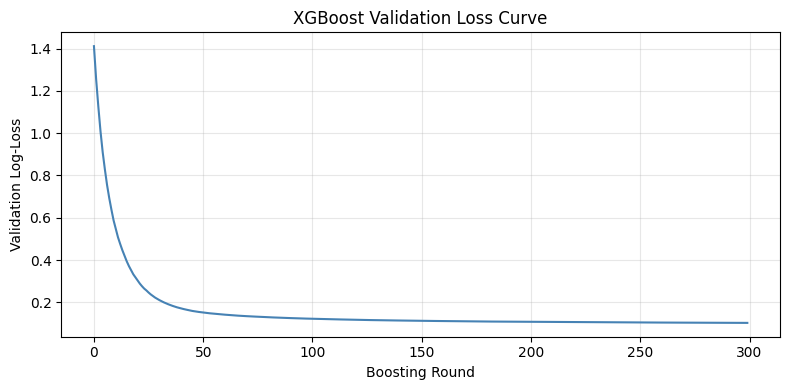

Final log-loss: 0.10261


In [19]:
# Validation loss curve — confirms convergence at 300 estimators
results = model.evals_result()
loss = results['validation_0']['mlogloss']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss, color='steelblue', linewidth=1.5)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Validation Log-Loss')
ax.set_title('XGBoost Validation Loss Curve')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/xgb_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final log-loss: {loss[-1]:.5f}')

In [ ]:
# Reload a saved model instead of retraining:
# model = XGBClassifier()
# model.load_model(MODEL_SAVE_PATH)
# print('Model loaded.')

---
## Section 5: Evaluate the Model

Accuracy, precision, recall, and macro F1 are reported across all classes. Macro F1 weights each class equally, so weak performance on rarer classes isn't masked by the common ones.

### 5.1 — Predictions & Confidence Scores

In [20]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# Confidence score = probability of the predicted class
confidence_scores = y_proba[np.arange(len(y_pred)), y_pred]
print(f'Mean confidence score: {confidence_scores.mean():.4f}')
print(f'Min confidence score:  {confidence_scores.min():.4f}')

Mean confidence score: 0.9699
Min confidence score:  0.2151


### 5.2 — Overall Metrics

In [21]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 45)
print(f'  Accuracy:         {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (macro):{precision:.4f}')
print(f'  Recall (macro):   {recall:.4f}')
print(f'  F1 (macro):       {f1_macro:.4f}')
print('=' * 45)
print()
print('Per-class report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

  Accuracy:         0.9636  (96.36%)
  Precision (macro):0.9534
  Recall (macro):   0.9728
  F1 (macro):       0.9614

Per-class report:
              precision    recall  f1-score   support

      benign       0.83      0.99      0.91     34173
        ddos       0.94      0.97      0.95     84056
         dos       1.00      0.94      0.97    126502
       probe       1.00      0.98      0.99     36659
         web       1.00      0.99      0.99     57661

    accuracy                           0.96    339051
   macro avg       0.95      0.97      0.96    339051
weighted avg       0.97      0.96      0.96    339051



### 5.3 — Confusion Matrix

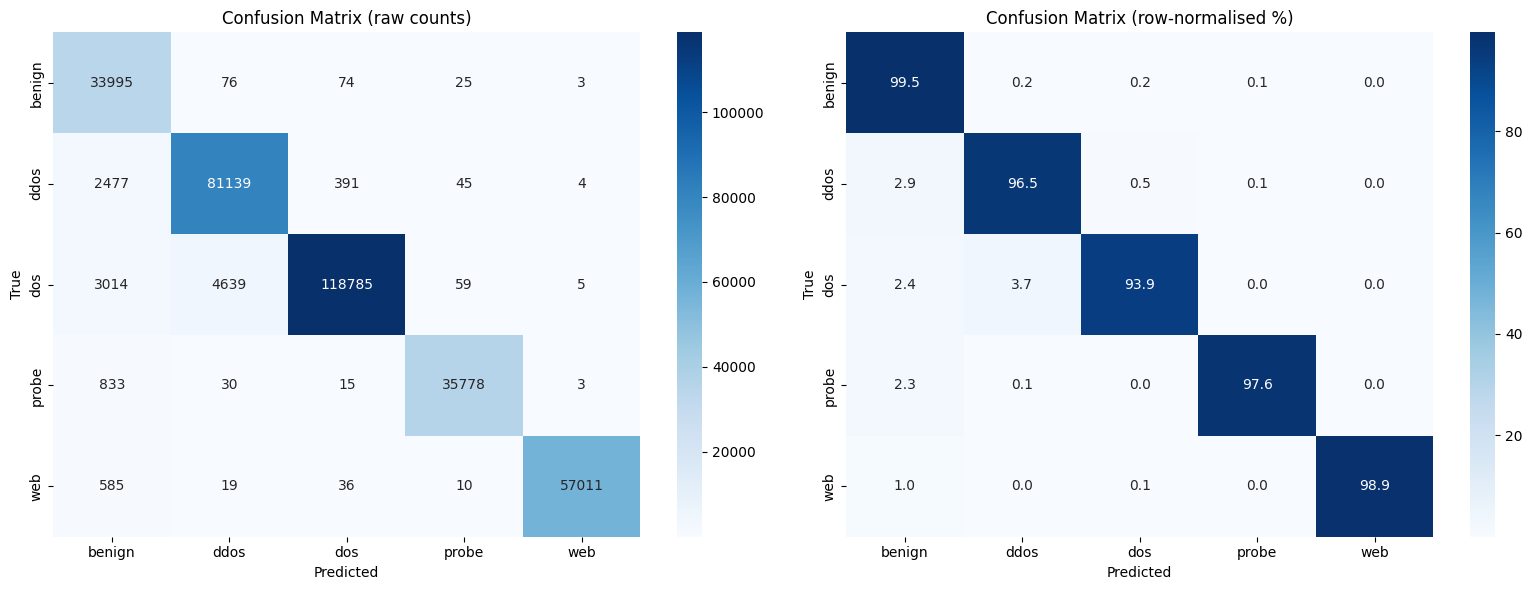

Saved confusion_matrix.png


In [22]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100   # row-normalised (%)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (raw counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Row-normalised (%)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalised %)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')

### 5.4 — Error Analysis
*Highlights misclassified pairs where >1% of a true class is predicted as another.*

In [23]:
# Flagging off-diagonal cells where >1% of a class gets misclassified as another

print('Noteworthy confusions (>1% of true class misclassified as another):')
found = False
for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        if true_idx != pred_idx:
            pct = cm_pct[true_idx, pred_idx]
            if pct > 1.0:
                print(f'  {CLASS_NAMES[true_idx]:12s} → predicted as {CLASS_NAMES[pred_idx]:12s}: {pct:.1f}%')
                found = True
if not found:
    print('  None — model is performing very well.')

Noteworthy confusions (>1% of true class misclassified as another):
  ddos         → predicted as benign      : 2.9%
  dos          → predicted as benign      : 2.4%
  dos          → predicted as ddos        : 3.7%
  probe        → predicted as benign      : 2.3%
  web          → predicted as benign      : 1.0%


---
## Section 6: CTI Alert Generation (Part 2.1)

Converts ML predictions into structured CTI alerts in JSON format. Each alert captures the predicted threat class, confidence score, alternative predictions, network observations, and the affected O-RAN component. The schema is inspired by STIX (Structured Threat Information eXpression) — the industry standard for machine-readable CTI — adopting the same principle of structured, typed JSON records designed for automated downstream processing.

Note: A basic alert (without SHAP evidence) is generated here. SHAP values are computed in Section 7, where the enriched alert is also shown, before being passed to the LLM in Section 8.

### 6.1 — Alert Generation Functions


In [24]:
from datetime import datetime, timezone

# O-RAN component mapping by attack category
# In production this would come from actual network topology config
COMPONENT_MAP = {
    'ddos':        'O-RAN Central Unit (O-CU)',
    'dos':         'O-RAN Central Unit (O-CU)',
    'probe':       'O-RAN Near-RT RIC',
    'web':         'O-RAN Application Layer / xApp Interface',
    'benign':      'N/A'
}

## required for bonus section
def get_shap_evidence(sample_idx_in_test, predicted_class_idx, top_n=5):
    """
    Compute SHAP values for one test sample and return the top-N
    features driving the predicted class, formatted for the CTI alert.
    """
    sample = X_test.iloc[[sample_idx_in_test]]
    sv_raw = explainer.shap_values(sample)

    # Normalise to list format
    if isinstance(sv_raw, np.ndarray) and sv_raw.ndim == 3:
        shap_for_pred_class = sv_raw[0, :, predicted_class_idx]
    else:
        shap_for_pred_class = sv_raw[predicted_class_idx][0]

    feature_names = X_test.columns.tolist()
    shap_series = pd.Series(shap_for_pred_class, index=feature_names)
    top_features = shap_series.abs().nlargest(top_n).index

    evidence = []
    for rank, feat in enumerate(top_features, start=1):
        val = shap_series[feat]
        evidence.append({
            'rank': rank,
            'feature': feat,
            'feature_value': float(sample[feat].iloc[0]),
            'shap_value': round(float(val), 4),
            # supports_prediction: positive SHAP pushes toward the predicted class
            # opposes_prediction:  negative SHAP pushes away from the predicted class
            'direction': 'supports_prediction' if val > 0 else 'opposes_prediction'
        })

    return evidence

def generate_cti_alert(test_sample_idx, include_shap=True, alert_id=None):
    """
    Generate a structured CTI alert JSON for a single test sample.

    Parameters:
        test_sample_idx : int  — index into X_test / y_test
        include_shap    : bool — whether to include SHAP evidence
        alert_id        : str  — optional custom alert ID

    Returns:
        dict — the structured CTI alert
    """
    row = X_test.iloc[test_sample_idx]
    proba = y_proba[test_sample_idx]              # probability over all classes
    pred_idx = int(y_pred[test_sample_idx])       # predicted class index
    pred_class = CLASS_NAMES[pred_idx]            # e.g. 'ddos'
    confidence = float(proba[pred_idx])

    # Top-3 predictions (sorted by probability)
    top3_idx = np.argsort(proba)[::-1][:3]
    alternatives = [
        {'class': CLASS_NAMES[i], 'confidence': round(float(proba[i]), 4)}
        for i in top3_idx if i != pred_idx
    ][:2]   # top-2 alternatives (excluding the prediction itself)

    # Decode categorical values back to readable strings
    proto_str   = feature_encoders['proto'].inverse_transform([int(row['proto'])])[0]
    service_str = feature_encoders['service'].inverse_transform([int(row['service'])])[0]
    state_str   = feature_encoders['conn_state'].inverse_transform([int(row['conn_state'])])[0]

    alert = {
        'alert_id': alert_id or f'CTI-{datetime.now(timezone.utc).strftime("%Y%m%d%H%M%S")}-{test_sample_idx:04d}',
        'schema_version': '1.0',
        'detection': {
            'timestamp': datetime.now(timezone.utc).isoformat(),
            'predicted_class': pred_class,
            'confidence': round(confidence, 4),
            'alternative_predictions': alternatives
        },
        'network_observations': {
            'protocol': proto_str,
            'service': service_str,
            'connection_state': state_str,
            'duration_sec': round(float(row['duration']), 6),
            'src_bytes': int(row['src_bytes']),
            'dst_bytes': int(row['dst_bytes']),
            'src_packets': int(row['src_pkts']),
            'dst_packets': int(row['dst_pkts']),
            'src_ip_bytes': int(row['src_ip_bytes']),
            'dst_ip_bytes': int(row['dst_ip_bytes']),
            'http_transactions': int(row['http_trans_depth']),
            'http_status_error': bool(row['http_status_error']),
            'file_transferred': bool(row['is_file_transfered'])
        },
        'affected_component': COMPONENT_MAP.get(pred_class, 'Unknown O-RAN Component'),
        'llm_assessment': None
    }

    if include_shap:
        shap_evidence = get_shap_evidence(test_sample_idx, pred_idx, top_n=5)
        # Human-readable summary of top SHAP driver
        top_feat = shap_evidence[0]
        direction_str = 'supported' if top_feat['direction'] == 'supports_prediction' else 'opposed'
        alert['shap_evidence'] = {
            'top_features': shap_evidence,
            'summary': (
                f"The feature '{top_feat['feature']}' (value={top_feat['feature_value']}) "
                f"{direction_str} the prediction most strongly (SHAP={top_feat['shap_value']})."
            )
        }

    return alert

print('generate_cti_alert() defined.')

generate_cti_alert() defined.


### 6.2 — Example Alert (Without SHAP)
*Generates a structured CTI alert for the test event at `DEMO_IDX` using the ML prediction alone — no SHAP evidence yet. Change `DEMO_IDX` to explore different events.*

*Expected output: the full alert JSON with `detection`, `network_observations`, and `affected_component` fields populated. The `llm_assessment` field will be `null` — the LLM enrichment happens in Section 8. The `shap_evidence` field is absent — that is added in Section 7.4.*

In [25]:
# Change DEMO_IDX to try different test events 

DEMO_IDX = 0

alert_no_shap = generate_cti_alert(DEMO_IDX, include_shap=False)

print(f"True label:      {CLASS_NAMES[y_test[DEMO_IDX]]}")
print(f"Predicted class: {alert_no_shap['detection']['predicted_class']}")
print(f"Confidence:      {alert_no_shap['detection']['confidence']}")
print()
print('Full CTI Alert (without SHAP):')
print(json.dumps(alert_no_shap, indent=2))

True label:      dos
Predicted class: dos
Confidence:      0.6306

Full CTI Alert (without SHAP):
{
  "alert_id": "CTI-20260703150845-0000",
  "schema_version": "1.0",
  "detection": {
    "timestamp": "2026-07-03T15:08:45.649880+00:00",
    "predicted_class": "dos",
    "confidence": 0.6306,
    "alternative_predictions": [
      {
        "class": "ddos",
        "confidence": 0.3617
      },
      {
        "class": "benign",
        "confidence": 0.0075
      }
    ]
  },
  "network_observations": {
    "protocol": "tcp",
    "service": "-",
    "connection_state": "S1",
    "duration_sec": 16.399745,
    "src_bytes": 0,
    "dst_bytes": 0,
    "src_packets": 2,
    "dst_packets": 6,
    "src_ip_bytes": 104,
    "dst_ip_bytes": 312,
    "http_transactions": 0,
    "http_status_error": false,
    "file_transferred": false
  },
  "affected_component": "O-RAN Central Unit (O-CU)",
  "llm_assessment": null
}


---
## Section 7: SHAP-Based Evidence — (Part 3)

SHAP (SHapley Additive exPlanations) quantifies the contribution of each feature to individual predictions. Values are computed prior to LLM enrichment so that feature-level evidence can be included in the CTI alert.

1. Compute SHAP values using TreeExplainer (exact, not approximate)
2. Global feature importance — beeswarm and bar chart
3. Per-class feature importance
4. `get_shap_evidence()` — per-sample top-N features for alert inclusion

### 7.1 — Compute SHAP Values
*TreeExplainer on a 2,000-sample subset of the test set.*

In [26]:
# Using 2000 samples for the global plot from the test set for speed
SHAP_SAMPLE_SIZE = 2000
shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test.iloc[shap_sample_idx]

print('Computing SHAP values...')
start = time.time()
explainer = shap.TreeExplainer(model)
shap_raw = explainer.shap_values(X_shap)
elapsed = time.time() - start
print(f'Done in {elapsed:.1f}s')

# Normalise to 2D list format: one (samples, features) array per class
# Case 1 — TreeExplainer returns 3D NumPy array (samples, features, classes)
if isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    shap_values = [shap_raw[:, :, i] for i in range(NUM_CLASSES)]
    print(f'SHAP values shape: {shap_raw.shape}  → converted to list of {NUM_CLASSES} x {shap_raw.shape[:2]}')
# Case 2 — TreeExplainer returns a list
else:
    shap_values = shap_raw
    print(f'SHAP values: list of {len(shap_values)} classes, each {np.array(shap_values[0]).shape}')

Computing SHAP values...
Done in 1.0s
SHAP values shape: (2000, 18, 5)  → converted to list of 5 x (2000, 18)


### 7.2 — Global Feature Importance
*Beeswarm plot shows importance, direction, and value distribution. Bar chart shows overall ranking.*

Top 10 globally important features:
  dst_port                  0.9018
  conn_state                0.7244
  src_port                  0.6372
  src_bytes                 0.4696
  http_status_error         0.4519
  duration                  0.3695
  files_total_bytes         0.3367
  dst_bytes                 0.2797
  src_ip_bytes              0.2620
  dst_ip_bytes              0.2110


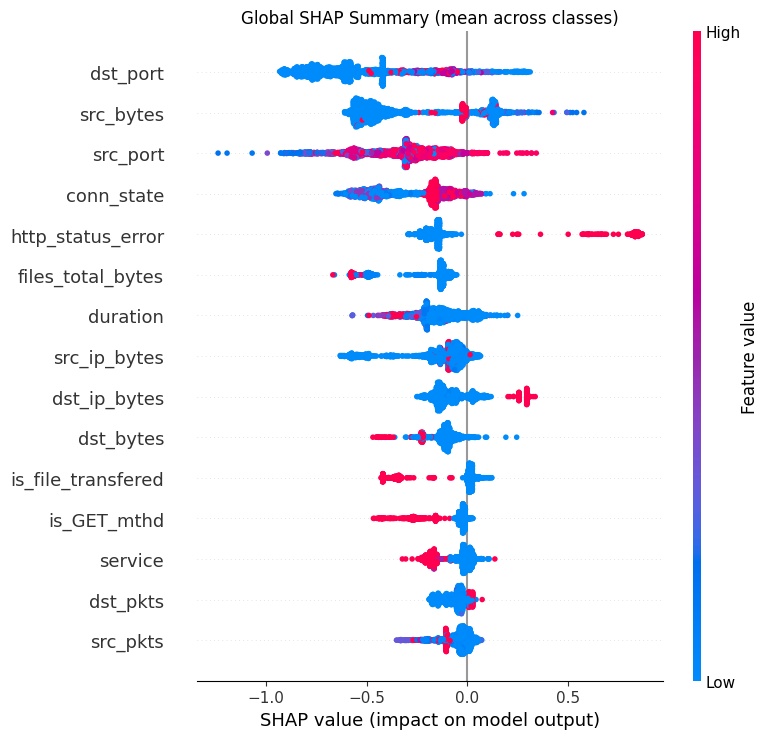

Saved: shap_global_beeswarm.png


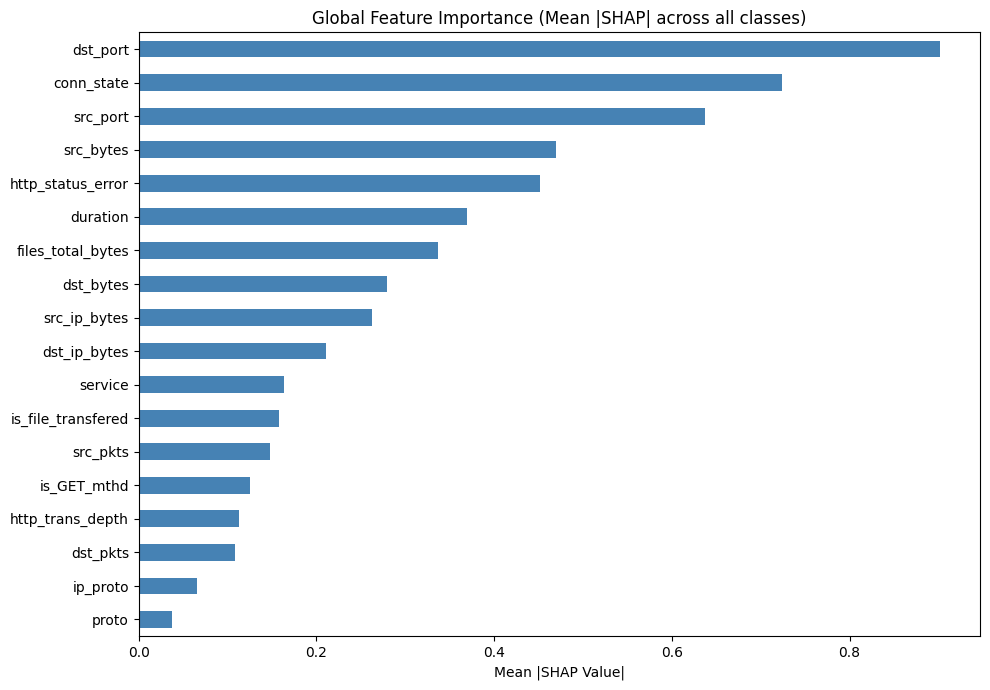

Saved: shap_global_importance.png


In [27]:
mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)   # (samples, features)
global_importance = pd.Series(mean_shap.mean(axis=0), index=X_test.columns).sort_values(ascending=False)

print('Top 10 globally important features:')
for feat, val in global_importance.head(10).items():
    print(f'  {feat:<25} {val:.4f}')

# --- Beeswarm plot ---
# Shows feature importance + direction of effect + value distribution
# Use mean SHAP across classes (shape: samples × features) for the global view
mean_shap_for_plot = np.mean(shap_values, axis=0)   # average contribution across classes
shap.summary_plot(
    mean_shap_for_plot, X_shap,
    feature_names=X_test.columns.tolist(),
    max_display=15, show=False
)
plt.title('Global SHAP Summary (mean across classes)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/shap_global_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_beeswarm.png')

# --- Bar chart (mean |SHAP|) ---
fig, ax = plt.subplots(figsize=(10, 7))
global_importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Global Feature Importance (Mean |SHAP| across all classes)')
ax.set_xlabel('Mean |SHAP Value|')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_importance.png')

### 7.3 — Per-Class Feature Importance
*Top features for each attack category.*

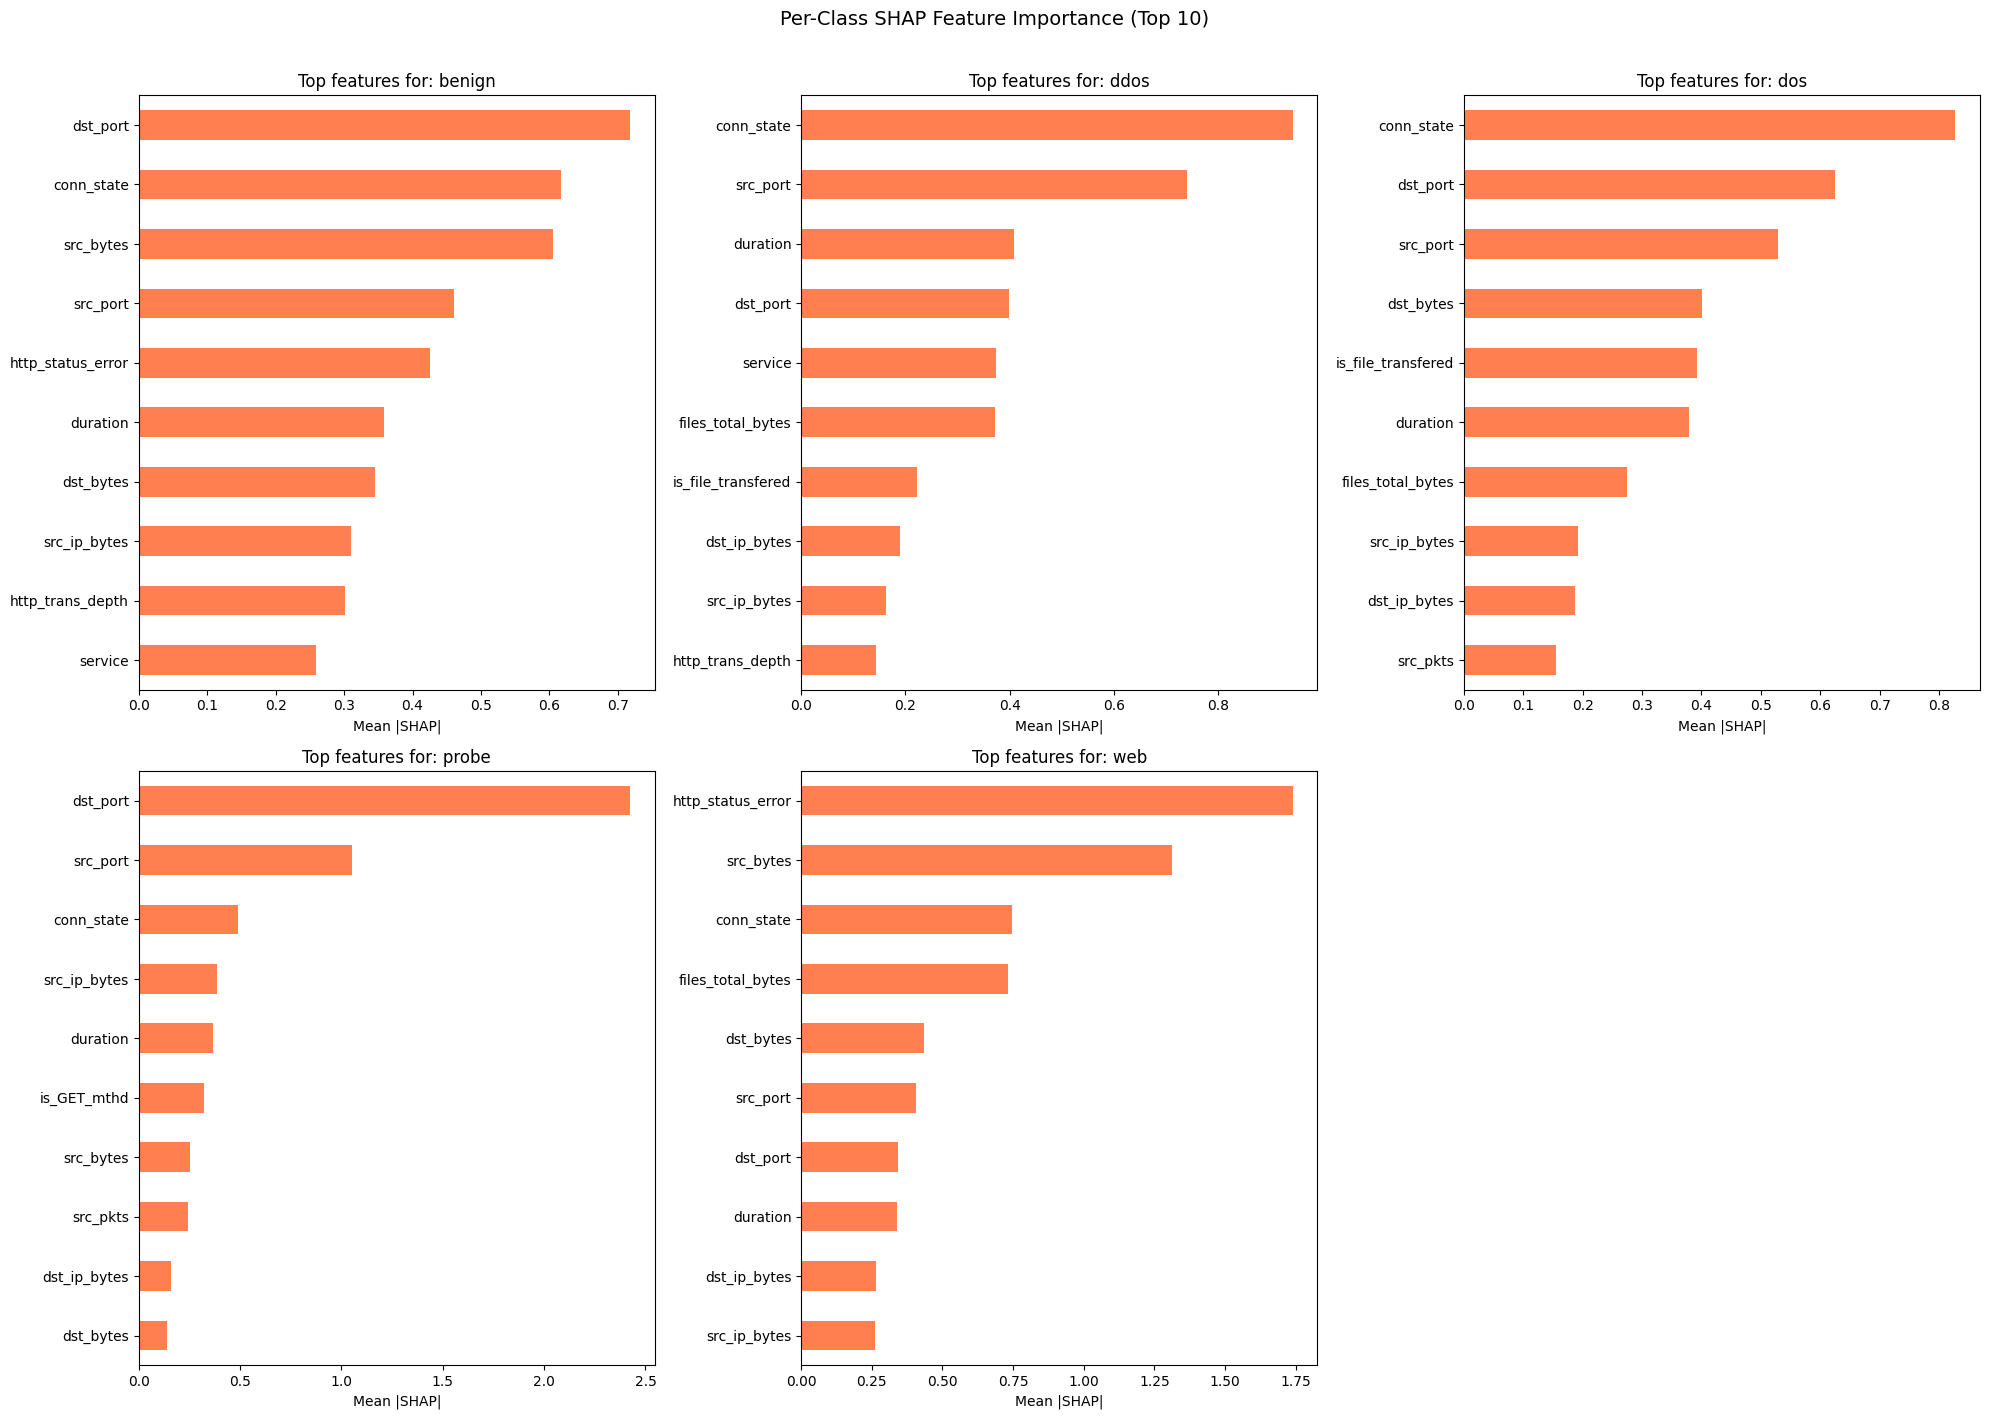

Saved: shap_per_class.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    # shap_values[i]: (samples, features) for class i
    shap_cls = pd.Series(np.abs(shap_values[i]).mean(axis=0), index=X_test.columns)
    shap_cls = shap_cls.sort_values(ascending=True).tail(10)
    shap_cls.plot(kind='barh', ax=axes[i], color='coral')
    axes[i].set_title(f'Top features for: {cls}')
    axes[i].set_xlabel('Mean |SHAP|')

axes[-1].set_visible(False)

plt.suptitle('Per-Class SHAP Feature Importance (Top 10)', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CTI/shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_per_class.png')

### 7.4 — Example Alert (With SHAP Evidence)
*The same alert as Section 6.2, now with SHAP evidence injected. This is the enriched alert that will be sent to the LLM in Section 8.*

*Expected output: the same alert JSON as 6.2 but with a new `shap_evidence` field containing the top 5 features that drove the prediction — each with its feature value, SHAP value, and direction (supports/opposes). `llm_assessment` is still `null` since this is the input to the LLM.*

In [29]:
alert_with_shap = generate_cti_alert(DEMO_IDX, include_shap=True)

print(f"True label:      {CLASS_NAMES[y_test[DEMO_IDX]]}")
print(f"Predicted class: {alert_with_shap['detection']['predicted_class']}")
print(f"Confidence:      {alert_with_shap['detection']['confidence']}")
print(f"SHAP features:   {len(alert_with_shap.get('shap_evidence', {}).get('top_features', []))}")
print()
print('Full CTI Alert (with SHAP):')
print(json.dumps(alert_with_shap, indent=2))

True label:      dos
Predicted class: dos
Confidence:      0.6306
SHAP features:   5

Full CTI Alert (with SHAP):
{
  "alert_id": "CTI-20260703150938-0000",
  "schema_version": "1.0",
  "detection": {
    "timestamp": "2026-07-03T15:09:38.069487+00:00",
    "predicted_class": "dos",
    "confidence": 0.6306,
    "alternative_predictions": [
      {
        "class": "ddos",
        "confidence": 0.3617
      },
      {
        "class": "benign",
        "confidence": 0.0075
      }
    ]
  },
  "network_observations": {
    "protocol": "tcp",
    "service": "-",
    "connection_state": "S1",
    "duration_sec": 16.399745,
    "src_bytes": 0,
    "dst_bytes": 0,
    "src_packets": 2,
    "dst_packets": 6,
    "src_ip_bytes": 104,
    "dst_ip_bytes": 312,
    "http_transactions": 0,
    "http_status_error": false,
    "file_transferred": false
  },
  "affected_component": "O-RAN Central Unit (O-CU)",
  "llm_assessment": null,
  "shap_evidence": {
    "top_features": [
      {
        "ran

---
## Section 8: LLM-Based CTI Enrichment (Part 2.2 + Part 3)

Qwen2.5-7B is deployed within the Colab runtime via Ollama. No external API is used — the model runs entirely within the session. The primary enrichment run uses the SHAP-enhanced alert, providing the model with feature-level evidence alongside the prediction.

`COMPARE_WITHOUT_SHAP = True` enables a second run without SHAP evidence, producing the data needed for the side-by-side comparison in Section 9.

### 8.1 — Setup Ollama
*Installs Ollama and pulls Qwen2.5-7B.*

In [30]:
# Only needed once per Colab session

# Install zstd (required by the Ollama installer) + lshw (GPU detection for Ollama)
!apt-get install -y zstd lshw -qq
# Install Ollama (lshw now present so GPU auto-detected)
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time

# Start Ollama server in background
subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)   # wait for server to start

# Pull the model (downloads ~4.5GB on first run — takes ~2 min on Colab)
!ollama pull qwen2.5:7b

print("Ollama ready.")

Selecting previously unselected package lshw.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../lshw_02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1_amd64.deb ...
Unpacking lshw (02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1) ...
Selecting previously unselected package pci.ids.
Preparing to unpack .../pci.ids_0.0~2022.01.22-1ubuntu0.1_all.deb ...
Unpacking pci.ids (0.0~2022.01.22-1ubuntu0.1) ...
Selecting previously unselected package usb.ids.
Preparing to unpack .../usb.ids_2022.04.02-1_all.deb ...
Unpacking usb.ids (2022.04.02-1) ...
Selecting previously unselected package zstd.
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up pci.ids (0.0~2022.01.22-1ubuntu0.1) ...
Setting up lshw (02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1) ...
Setting up usb.ids (2022.04.02-1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installi

### 8.2 — Threat Knowledge Base
*Domain context injected into the system prompt. Sources: MITRE ATT&CK for 5G, ENISA 5G Threat Landscape.*

In [39]:
# Grounding the LLM in domain-specific context rather than relying on training knowledge
# Sources: MITRE ATT&CK for 5G, ENISA Threat Landscape for 5G Networks
# Indicator field names below match the alert schema the LLM receives:
#   - network_observations keys: src_packets, dst_packets, http_transactions,
#     http_status_error, file_transferred, connection_state, ...
#   - port / raw-column features (dst_port, is_GET_mthd) surface via shap_evidence

THREAT_KNOWLEDGE = """
## 5G O-RAN Threat Knowledge Base

### O-RAN Architecture Components
- O-RU (Radio Unit): Physical radio transmission/reception at cell sites
- O-DU (Distributed Unit): Lower-layer protocol processing (PHY, MAC, RLC)
- O-CU (Central Unit): Higher-layer protocol processing (PDCP, RRC, SDAP)
- Near-RT RIC: Near-Real-Time RAN Intelligent Controller — runs xApps for intelligent RAN management
- SMO: Service Management and Orchestration — lifecycle management of network functions

### Known Attack Types and Behaviours

**DoS (Denial of Service):**
Single-source flooding attacks targeting O-RAN components. Common subtypes:
- SYN Flood: Sends large volumes of TCP SYN packets without completing handshake, exhausting connection tables
- UDP Flood: High-rate UDP packets to random ports, consuming bandwidth and CPU
- ICMP Flood: Ping flood exhausting processing resources
- Slowloris: Sends partial HTTP headers slowly, holding connections open to exhaust server threads
Indicators: High src_packets, near-zero dst_packets (one-directional), short duration_sec, RSTRH/S0 connection_state values

**DDoS (Distributed Denial of Service):**
Multi-source flooding. Same subtypes as DoS but originating from many sources simultaneously.
More difficult to block than single-source DoS. Can overwhelm O-CU bandwidth.
Indicators: Same flow-level signatures as DoS (high packet rate, one-directional traffic); source diversity
is not observable from per-flow features alone and requires aggregation across flows.

**Probe / Reconnaissance:**
Scanning attacks to discover network topology before launching targeted attacks.
- TCP Port Scan: Systematically checks which ports are open on target
- UDP Port Scan: Similar to TCP but using UDP probes
- OS Fingerprinting: Analyses TCP/IP stack responses to determine target OS
Indicators: Low bytes per flow (low src_bytes/dst_bytes), SYN-only or SYN-RST connection_state, no established
connections; the probed destination port appears as dst_port in the SHAP evidence when it drives the prediction
Target: Near-RT RIC and SMO interfaces are common reconnaissance targets

**Web Attacks:**
Application-layer attacks targeting O-RAN web interfaces and xApp APIs.
- HTTP Flood: High-rate legitimate-looking HTTP GET/POST requests to overwhelm web server
- SQL Injection: Malicious SQL in HTTP parameters to extract or corrupt database contents
- XSS (Cross-Site Scripting): Injects scripts into web responses
Indicators: Elevated http_transactions, http_status_error=True, file_transferred=True; GET-heavy request
patterns may surface as is_GET_mthd in the SHAP evidence
"""

print('Threat knowledge base defined.')

Threat knowledge base defined.


### 8.3 — Enrichment Function

In [40]:
import ollama as ollama_client

LLM_MODEL = 'qwen2.5:7b'

SYSTEM_PROMPT = f"""You are a cybersecurity analyst specialising in 5G Open Radio Access Network (O-RAN) security.
You analyse structured network threat alerts and produce detailed, structured incident assessments.

{THREAT_KNOWLEDGE}

ASSESSMENT RULES:
1. Base your assessment ONLY on information in the provided alert. Do not invent IP addresses, port numbers, timestamps, packet counts, or any other indicators not present in the alert.
2. If evidence is insufficient to make a confident determination, state this explicitly rather than guessing.
3. Your severity rating MUST be justified by specific observations from the alert (quote field names and values).
4. When SHAP evidence is provided, you MUST reference specific features by name when assigning severity and recommending a response.
5. Output ONLY valid JSON — no markdown, no prose outside the JSON object.

SEVERITY GUIDELINES (O-RAN context):
Severity combines three factors: detection confidence, attack impact, and the criticality of the affected O-RAN component. Control-plane components (Near-RT RIC, SMO) rank above user-plane components (O-CU, O-DU, O-RU), which rank above application / xApp interfaces.
- LOW: confidence < 0.55, OR benign traffic, OR low-rate scanning / a single failed connection attempt.
- MEDIUM: a confirmed reconnaissance / probe (scanning is preparatory, not yet damaging), OR any active attack at moderate confidence (0.55-0.84).
- HIGH: a high-confidence (>= 0.85) active attack — DoS/DDoS flooding or web exploitation (e.g. SQL injection, XSS) — on a user-plane or application component (O-CU, O-DU, xApp / application interface).
- CRITICAL: a high-confidence (>= 0.85) active attack on a control-plane component (Near-RT RIC or SMO), OR clear data exfiltration from any component.
Rules:
- Reconnaissance / probe never exceeds MEDIUM on its own.
- Never assign CRITICAL when confidence < 0.85.
- Always set human_review_required = true when confidence < 0.75 or severity is HIGH or CRITICAL."""

def enrich_alert_with_llm(alert_dict):
    """
    Send a CTI alert to Qwen2.5-7B and get back a structured assessment.

    Returns:
        (assessment_dict, elapsed_seconds)
    """
    user_prompt = f"""Analyse the following CTI alert for a 5G O-RAN network and provide a structured assessment.

CTI ALERT:
{json.dumps(alert_dict, indent=2)}

Respond ONLY with a JSON object in this exact format:
{{
  "threat_contextualisation": "<describe what is happening based on the alert observations>",
  "attack_correlation": "<correlate with known attack behaviours from the knowledge base>",
  "possible_impact": "<what could happen to the O-RAN network if this attack succeeds>",
  "severity": "<LOW|MEDIUM|HIGH|CRITICAL>",
  "severity_justification": "<cite specific field values from the alert that drove this severity rating>",
  "immediate_response": "<specific actions to take in the next 15 minutes>",
  "longer_term_mitigation": "<architectural or policy changes to prevent recurrence>",
  "human_review_required": <true|false>,
  "human_review_reason": "<why human review is or is not needed>"
}}"""

    start = time.time()
    response = ollama_client.chat(
        model=LLM_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': user_prompt}
        ],
        options={'temperature': 0.1, 'num_predict': 1024}  # low temp for consistent structured output
    )
    elapsed = time.time() - start

    raw_text = response['message']['content'].strip()

    # Strip markdown code fences if model wraps output in ```json ... ```
    if raw_text.startswith('```'):
        raw_text = raw_text.split('```')[1]
        if raw_text.startswith('json'):
            raw_text = raw_text[4:]

    try:
        assessment = json.loads(raw_text)
    except json.JSONDecodeError:
        # JSON parse failed — return raw text for debugging
        assessment = {'error': 'JSON parse failed', 'raw_response': raw_text}

    return assessment, elapsed

print('enrich_alert_with_llm() defined.')

enrich_alert_with_llm() defined.


### 8.4 — Run LLM Enrichment
*Sends the SHAP-enhanced alert to Qwen2.5-7B and receives a structured 9-field CTI assessment. If `COMPARE_WITHOUT_SHAP = True`, the basic alert (without SHAP) is also sent for comparison.*

*Expected output: one or two LLM assessment JSONs with fields including `threat_contextualisation`, `severity`, `immediate_response`, and `human_review_required`.*

In [41]:
# Warm-up: force the one-time model load so timed runs in next cell measure generation only
ollama_client.chat(
    model=LLM_MODEL,
    messages=[{'role': 'user', 'content': 'ping'}],
    options={'num_predict': 1},
)
print('Model warmed up.')

Model warmed up.


In [42]:
# SHAP is computed — primary run uses the SHAP-enhanced alert.
# Set COMPARE_WITHOUT_SHAP = True to also run without SHAP for comparison.

COMPARE_WITHOUT_SHAP = True

# Primary run: with SHAP evidence
alert_with_shap = generate_cti_alert(DEMO_IDX, include_shap=True)
print(f'Sending SHAP-enhanced alert to {LLM_MODEL}...')
assessment_with_shap, elapsed_with = enrich_alert_with_llm(alert_with_shap)
print(f'Generation time (with SHAP): {elapsed_with:.1f}s')
print(json.dumps(assessment_with_shap, indent=2))

# Optional comparison run: without SHAP
if COMPARE_WITHOUT_SHAP:
    print(f'\nSending basic alert to {LLM_MODEL} (no SHAP)...')
    assessment_no_shap, elapsed_no_shap = enrich_alert_with_llm(alert_no_shap)
    print(f'Generation time (without SHAP): {elapsed_no_shap:.1f}s')
    print(json.dumps(assessment_no_shap, indent=2))

Sending SHAP-enhanced alert to qwen2.5:7b...
Generation time (with SHAP): 13.6s
{
  "threat_contextualisation": "The alert indicates a potential DoS attack targeting the O-CU, with two TCP packets sent from an external source to port 443 (HTTPS) over a duration of 16.399745 seconds. The low byte count and high packet count suggest that this is likely a probing or reconnaissance activity.",
  "attack_correlation": "This behavior aligns with the known attack type 'Probe / Reconnaissance', specifically a TCP port scan targeting common web service ports like HTTPS (port 443).",
  "possible_impact": "If successful, such scanning could reveal vulnerabilities in the O-CU's web interface, potentially allowing an attacker to gain insights into network configurations or launch more targeted attacks.",
  "severity": "MEDIUM",
  "severity_justification": "The confidence level is 0.6306, which falls between benign and active attack categories. The attack is probing rather than actively damaging the

---
## Section 9: LLM Output Evaluation (Part 2.3)

1. Hallucination check — did the LLM invent indicators not in the alert?
2. Side-by-side comparison — with vs without SHAP

### 9.1 — Hallucination Check
*Five heuristic checks on the LLM assessment:*
- **Fabricated numeric values** — flags numbers in the output not present in the alert (float comparison to handle LLM rounding)
- **Invented IP addresses** — any specific IP pattern in the output is hallucinated (src_ip/dst_ip are dropped from the model)
- **Severity/confidence contradiction** — e.g. CRITICAL at low confidence, or LOW at high confidence
- **DoS/distributed confusion** — flags distributed-attack language when the predicted class is single-source DoS
- **Schema completeness** — all 9 assessment fields must be present and non-empty

In [43]:
# Heuristic hallucination checks on the LLM assessment.
# Catches: fabricated numeric values, invented IP addresses, severity/confidence
# contradictions, dos/distributed confusion, and missing schema fields.
# Limitation: qualitative hallucinations (e.g. "high packet rate" on low-traffic
# flows) require a second LLM pass to detect and are not checked here.

import re

REQUIRED_FIELDS = [
    'threat_contextualisation', 'attack_correlation', 'possible_impact',
    'severity', 'severity_justification', 'immediate_response',
    'longer_term_mitigation', 'human_review_required', 'human_review_reason',
]

def check_hallucinations(assessment, alert, verbose=True):
    issues = []
    assessment_text = json.dumps(assessment).lower()

    # 1. Numeric grounding — only on descriptive fields (response/mitigation text
    #    legitimately contains generic numbers like "60-second", "30 days").
    GROUNDED_FIELDS = ['threat_contextualisation', 'attack_correlation', 'severity_justification']
    grounded_text = ' '.join(str(assessment.get(f, '')) for f in GROUNDED_FIELDS)

    def extract_nums(text):
        nums = []
        for m in re.finditer(r'(\d+\.?\d*)\s*(%?)', text):
            v = float(m.group(1))
            nums.append(v / 100 if m.group(2) else v)   # 63% -> 0.63
        return nums
    alert_nums    = [float(x) for x in re.findall(r'\b\d+\.?\d*\b', json.dumps(alert))]
    invented_nums = {
        n for n in extract_nums(grounded_text)
        if n >= 16 and not any(abs(n - a) <= max(0.5, 0.01 * abs(a)) for a in alert_nums)
    }
    if invented_nums:
        issues.append(f"Fabricated numeric values: {invented_nums}")

    # 2. IP addresses — src_ip/dst_ip are dropped from the model, so any IP in
    #    the output is hallucinated (not grounded in the alert)
    ip_re = re.compile(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b')
    alert_ips = set(ip_re.findall(json.dumps(alert)))
    invented_ips = set(ip_re.findall(json.dumps(assessment))) - alert_ips
    if invented_ips:
        issues.append(f"Hallucinated IP addresses: {invented_ips}")

    # 3. Severity vs confidence consistency
    confidence = alert['detection']['confidence']
    severity = assessment.get('severity', '').upper()
    if confidence < 0.5 and severity == 'CRITICAL':
        issues.append(f"Severity CRITICAL inconsistent with low confidence ({confidence:.2f})")
    if confidence > 0.9 and severity == 'LOW':
        issues.append(f"Severity LOW inconsistent with high confidence ({confidence:.2f})")
    if (confidence < 0.75 or severity in ('HIGH', 'CRITICAL')) and assessment.get('human_review_required') is False:
        issues.append(f"human_review_required=False violates policy (conf={confidence:.2f}, severity={severity})")

    # 4. DoS vs distributed language — dos is single-source by definition
    predicted = alert['detection']['predicted_class']
    if predicted == 'dos':
        dist_words = ['distributed', 'multiple source', 'multiple ip', 'botnet', 'multi-source']
        if any(w in assessment_text for w in dist_words):
            issues.append("DoS prediction but assessment uses distributed/multi-source language")

    # 5. Schema completeness
    missing = [f for f in REQUIRED_FIELDS if f not in assessment or assessment[f] == '' or assessment[f] is None]
    if missing:
        issues.append(f"Missing or empty fields: {missing}")

    # Report
    if verbose:
        if issues:
            for issue in issues:
                print(f"  WARNING: {issue}")
        else:
            print("  No issues detected.")
        print(f"  Severity '{severity}' — {'valid' if severity in ('LOW','MEDIUM','HIGH','CRITICAL') else 'WARNING: unexpected value'}.")
        print(f"  Predicted class '{predicted}' {'referenced' if predicted.lower() in assessment_text else 'NOT FOUND'} in assessment.")

    return issues

print('Hallucination check (WITH SHAP):')
check_hallucinations(assessment_with_shap, alert_with_shap)

if COMPARE_WITHOUT_SHAP:
    print('\nHallucination check (WITHOUT SHAP):')
    check_hallucinations(assessment_no_shap, alert_no_shap)


Hallucination check (WITH SHAP):
  No issues detected.
  Severity 'MEDIUM' — valid.
  Predicted class 'dos' referenced in assessment.

Hallucination check (WITHOUT SHAP):
  No issues detected.
  Severity 'MEDIUM' — valid.
  Predicted class 'dos' referenced in assessment.


### 9.2 — SHAP vs No-SHAP Comparison
*Side-by-side diff of the two LLM assessments from Section 8.4 — with and without SHAP evidence. Fields marked `<<< CHANGED` differ between the two runs. Requires `COMPARE_WITHOUT_SHAP = True` in Section 8.*

*Expected output: a field-by-field comparison showing how SHAP evidence changes the LLM's reasoning — e.g. generic monitoring advice becomes port-specific rate limiting, and `human_review_required` may flip from False to True when SHAP reveals ambiguous evidence.*

In [44]:
# Requires COMPARE_WITHOUT_SHAP = True in Section 8

if not COMPARE_WITHOUT_SHAP:
    print("Set COMPARE_WITHOUT_SHAP = True in Section 8 and re-run to enable this comparison.")
else:
    compare_fields = [
        'severity',
        'severity_justification',
        'immediate_response',
        'longer_term_mitigation',
        'human_review_required',
        'human_review_reason',
    ]

    print(f"True label : {CLASS_NAMES[y_test[DEMO_IDX]]}")
    print(f"Predicted  : {alert_with_shap['detection']['predicted_class']} (conf={alert_with_shap['detection']['confidence']})")
    print(f"Generation : without SHAP {elapsed_no_shap:.1f}s  |  with SHAP {elapsed_with:.1f}s")
    print()

    for field in compare_fields:
        v_without = str(assessment_no_shap.get(field, 'N/A'))
        v_with    = str(assessment_with_shap.get(field, 'N/A'))
        changed   = v_without != v_with
        marker    = '  <<< CHANGED' if changed else ''
        print(f"{'─' * 70}")
        print(f"{field}{marker}")
        print(f"  WITHOUT: {v_without}")
        print(f"  WITH:    {v_with}")
    print(f"{'─' * 70}")


True label : dos
Predicted  : dos (conf=0.6306)
Generation : without SHAP 12.4s  |  with SHAP 13.6s

──────────────────────────────────────────────────────────────────────
severity
  WITHOUT: MEDIUM
  WITH:    MEDIUM
──────────────────────────────────────────────────────────────────────
severity_justification  <<< CHANGED
  WITHOUT: The confidence level is 0.63, which falls within the medium range (0.55-0.84). The attack is suspected of being a probe/reconnaissance activity targeting the O-CU, which is a user-plane component.
  WITH:    The confidence level is 0.6306, which falls between benign and active attack categories. The attack is probing rather than actively damaging the system, but it targets a critical component (O-CU).
──────────────────────────────────────────────────────────────────────
immediate_response  <<< CHANGED
  WITHOUT: Implement rate limiting on incoming TCP connections to the O-CU and monitor for any unusual traffic patterns. Consider temporarily blocking suspic